## 🌱 Carbon Footprint & Green Code Analyzer (Capstone Project)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
emission_df = pd.read_csv('capstone_dataset\\annual-co2-emissions-per-country.csv')
emission_df.head()

,Entity,Code,Year,Annual CO₂ emissions
0,Afghanistan,AFG,1949,14656.0
1,Afghanistan,AFG,1950,84272.0
2,Afghanistan,AFG,1951,91600.0
3,Afghanistan,AFG,1952,91600.0
4,Afghanistan,AFG,1953,106256.0


In [3]:
emission_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29384 entries, 0 to 29383
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Entity                29384 non-null  object 
 1   Code                  23714 non-null  object 
 2   Year                  29384 non-null  int64  
 3   Annual CO₂ emissions  29384 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 918.4+ KB


In [4]:
emission_df.describe()

,Year,Annual CO₂ emissions
count,29384.000000,2.938400e+04
mean,1948.359243,4.202270e+08
std,59.148142,1.972092e+09
min,1750.000000,0.000000e+00
25%,1913.000000,3.810560e+05
50%,1963.000000,5.080756e+06
75%,1995.000000,5.365634e+07
max,2024.000000,3.859858e+10


In [5]:
emission_df = emission_df.drop(columns=["Code"])
emission_df = emission_df.rename(columns={"Annual CO₂ emissions" : "co2"})
emission_df.head()

,Entity,Year,co2
0,Afghanistan,1949,14656.0
1,Afghanistan,1950,84272.0
2,Afghanistan,1951,91600.0
3,Afghanistan,1952,91600.0
4,Afghanistan,1953,106256.0


In [6]:
emission_df.isnull().sum()

Entity    0
Year      0
co2       0
dtype: int64

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
emission_df["Entity_encoded"] = le.fit_transform(emission_df["Entity"])

emission_df.head(234)

,Entity,Year,co2,Entity_encoded
0,Afghanistan,1949,14656.0,0
1,Afghanistan,1950,84272.0,0
2,Afghanistan,1951,91600.0,0
3,Afghanistan,1952,91600.0,0
4,Afghanistan,1953,106256.0,0
...,...,...,...,...
229,Africa (GCP),1862,0.0,2
230,Africa (GCP),1863,0.0,2
231,Africa (GCP),1864,0.0,2
232,Africa (GCP),1865,0.0,2


In [ ]:
# Encode country
emission_df["Entity_encoded"] = le.fit_transform(emission_df["Entity"])

# 🔹 Normalize year (NEW — add this)
emission_df["year_norm"] = emission_df["Year"] - emission_df["Year"].min()

# Feature + target split
X = emission_df[["Entity_encoded", "year_norm"]]
y = np.log1p(emission_df["Annual CO₂ emissions"])


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [11]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

print(type(model))
model.fit(X_train, y_train)

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [12]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("R² Score:", r2)

Mean Absolute Error (MAE): 11716157.85890278
R² Score: 0.9990692991644886


In [13]:
def predict_co2(country, year):
    try:
        encoded_country = le.transform([country])[0]
        prediction = model.predict([[encoded_country, year]])
        return prediction
    except:
        return "Country not Found!"

In [14]:
predict_co2("India", 2025)

c:\Users\Lakshay\Desktop\SPCR\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([3.08703983e+09])

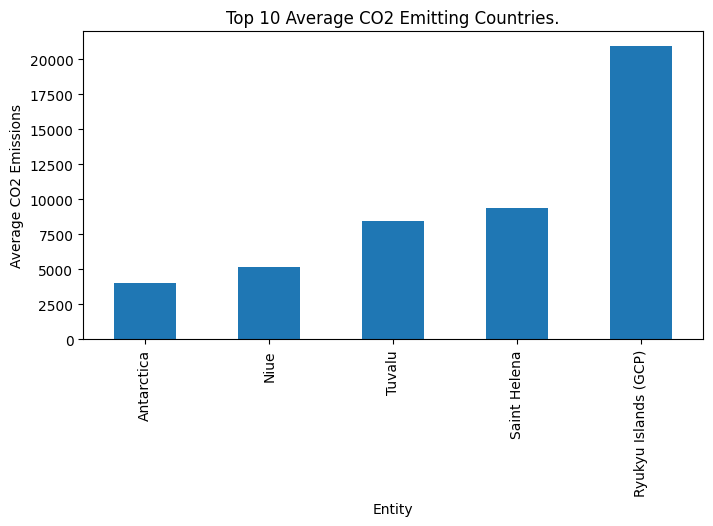

In [15]:
top_10 = (
    emission_df.groupby("Entity")['co2']
    .mean()
    .sort_values()
    .head()
)

top_10.plot(kind='bar', figsize=(8,4), title="Top 10 Average CO2 Emitting Countries.")
plt.ylabel("Average CO2 Emissions")
plt.show()

In [16]:
def analyze_code(code):
    score = 100
    issues = []

    if "range(1000000)" in code:
        score -= 30
        issues.append("Large loop detected")

    if code.count("print") > 5:
        score -= 20
        issues.append("Too many print statements")

    return score, issues

In [17]:
sample_code = """
for i in range(1000000):
    print(i)
"""
analyze_code(sample_code)

(70, ['Large loop detected'])

In [18]:
import joblib

joblib.dump(model, "rf_model.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model and encoder saved using joblib")

Model and encoder saved using joblib


In [21]:
loaded_model = joblib.load('rf_model.pkl')
loaded_encoder = joblib.load('label_encoder.pkl')

country_encoded = loaded_encoder.transform(['India'])[0]
loaded_model.predict([[country_encoded, 2025]])

c:\Users\Lakshay\Desktop\SPCR\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([3.08703983e+09])

In [22]:
def predict_co2_loaded(country, year):
    try:
        encoded = loaded_encoder.transform([country])[0]
        return float(loaded_model.predict([[encoded, year]])[0])
    except:
        return "Country not found"

In [26]:
predict_co2_loaded("India", 2025)

c:\Users\Lakshay\Desktop\SPCR\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


3087039826.0

In [35]:
pred = predict_co2_loaded("India", 2000)

print(f"Predicted CO₂ Emissions: {pred:,.2f}")

Predicted CO₂ Emissions: 3,087,039,826.00


c:\Users\Lakshay\Desktop\SPCR\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [36]:
importances = model.feature_importances_
print(importances)

[0.64728599 0.35271401]
